#Project 3A - Historical Traffic Analysis

**Authored by:**

1. **TIEN DAT HOANG:** Preprocessing
2. **LILY TRAN:** Model Training
3. **RUKSHAN DIAS:** Fine tunning
4. **QUANG AN QUOC TRAN:** LLM explanation
5. **PRIYANSHU CAULEECHURN:** Prompt engineering
6. **QIZHE YEW:** Retrieval-Augmented Generation

**Duration:** 90 mins

**Level:** Intermediate

**Pre-requisite Skills:** Python, Data cleaning, Data analysis, Data visualisation, Time-Series Analysis, Feature Engineering, Optimisation Methods, Deep Learning

### Scenario

Traffic congestion is a common issue in urban areas, often caused by recurring daily patterns and influenced by factors such as time and location. In this project, the focus is on analysing historical traffic data to understand how traffic volume changes over time.

By exploring traffic counts across different hours and days, key patterns such as peak periods can be identified. These insights form the foundation for building predictive models and can later be extended with additional data such as weather and events.

### Introduction

This project focuses on analysing historical traffic data and building models to predict traffic volume. The data is transformed into an hourly format, and key time-based features are engineered to capture traffic patterns.

Machine learning models are then applied to predict traffic count using these features, providing a baseline for understanding traffic behaviour. This stage serves as a foundation for future extensions, including the integration of weather data and explainable AI techniques.

## DATA PREPROCESSING

### Importing libraries and reading datasets

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

jan = pd.read_csv("/content/drive/MyDrive/TransportActivityCount_2026_January.csv")
feb = pd.read_csv("/content/drive/MyDrive/TransportActivityCount_2026_February.csv")
q1_2025 = pd.read_csv("/content/drive/MyDrive/TransportActivityCount_2025_1.csv")
q2_2025 = pd.read_csv("/content/drive/MyDrive/TransportActivityCount_2025_2.csv")
q3_2025 = pd.read_csv("/content/drive/MyDrive/TransportActivityCount_2025_3.csv")
q4_2025 = pd.read_csv("/content/drive/MyDrive/TransportActivityCount_2025_4.csv")

print(jan.columns)
print(q1_2025.columns)

Index(['countLocationId', 'countLocationName', 'CountLocationLat',
       'CountLocationLong', 'from', 'to', 'class', 'count'],
      dtype='object')
Index(['countLocationId', 'countLocationName', 'CountLocationLat',
       'CountLocationLong', 'from', 'to', 'class', 'count'],
      dtype='object')


### Concatenating datasets

In [3]:
df = pd.concat([q1_2025, q2_2025, q3_2025, q4_2025, jan, feb], ignore_index=True)
df.head()

,countLocationId,countLocationName,CountLocationLat,CountLocationLong,from,to,class,count
0,51228,Yarra Promenade - East Path,-37.821459,144.960343,2025-01-01T00:00:00.000Z,2025-01-01T00:05:00.000Z,pedestrian,313
1,45217,Royal Park Tram Track- CoM Pole 2773,-37.791020,144.949562,2025-01-01T00:00:00.000Z,2025-01-01T00:05:00.000Z,pedestrian,1
2,43775,Swanston St Asset ID: COM1757,-37.808159,144.963052,2025-01-01T00:00:00.000Z,2025-01-01T00:05:00.000Z,cyclist,1
3,44864,Royal Park Asset ID:COM2705,-37.795462,144.952063,2025-01-01T00:00:00.000Z,2025-01-01T00:05:00.000Z,pedestrian,2
4,51281,Yarra Promenade - West Path,-37.822354,144.958747,2025-01-01T00:00:00.000Z,2025-01-01T00:05:00.000Z,pedestrian,61


This code block imports the January and February 2026 and the 4 quarters of 2025 transport activity datasets  and combines them into a single unified DataFrame. By merging multiple months of data, the analysis gains improved temporal coverage and robustness. The concatenation process ensures that all observations are retained while resetting the index for consistency. Finally, the dataset preview is displayed to verify successful loading and integration

### Initial Inspection

In [4]:
print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Column names:
Index(['countLocationId', 'countLocationName', 'CountLocationLat',
       'CountLocationLong', 'from', 'to', 'class', 'count'],
      dtype='object')

Data types:
countLocationId        int64
countLocationName     object
CountLocationLat     float64
CountLocationLong    float64
from                  object
to                    object
class                 object
count                  int64
dtype: object

Missing values:
countLocationId         0
countLocationName    4183
CountLocationLat     4183
CountLocationLong    4183
from                    0
to                      0
class                   0
count                   0
dtype: int64

Duplicate rows: 700180


This block performs an initial inspection of the combined dataset. It prints the column names so we can understand the structure of the data, checks the data types of each column, counts the missing values in every column, and calculates how many rows are duplicated. This is an important exploratory cleaning step because it helps us understand the raw data before making any modifications.

In [5]:
df = df.drop_duplicates().copy()
df = df.dropna(subset=["countLocationName"]).copy()
print(df.shape)
print(df.isnull().sum())

(5791642, 8)
countLocationId      0
countLocationName    0
CountLocationLat     0
CountLocationLong    0
from                 0
to                   0
class                0
count                0
dtype: int64


### Date Time Conversion

In [6]:
df["from"] = pd.to_datetime(df["from"], errors="coerce")
df["to"] = pd.to_datetime(df["to"], errors="coerce")

# Remove rows where datetime conversion failed
df = df.dropna(subset=["from", "to"]).copy()

### Datetime Validation and Duration Creation

This block converts the from and to columns into datetime format so they can be used for time-based analysis.

In [7]:
# Remove rows where 'to' is earlier than 'from'
df = df[df["to"] >= df["from"]].copy()

# Create duration in minutes
df["duration_minutes"] = (df["to"] - df["from"]).dt.total_seconds() / 60
df.head()

,countLocationId,countLocationName,CountLocationLat,CountLocationLong,from,to,class,count,duration_minutes
0,51228,Yarra Promenade - East Path,-37.821459,144.960343,2025-01-01 00:00:00+00:00,2025-01-01 00:05:00+00:00,pedestrian,313,5.0
1,45217,Royal Park Tram Track- CoM Pole 2773,-37.791020,144.949562,2025-01-01 00:00:00+00:00,2025-01-01 00:05:00+00:00,pedestrian,1,5.0
2,43775,Swanston St Asset ID: COM1757,-37.808159,144.963052,2025-01-01 00:00:00+00:00,2025-01-01 00:05:00+00:00,cyclist,1,5.0
3,44864,Royal Park Asset ID:COM2705,-37.795462,144.952063,2025-01-01 00:00:00+00:00,2025-01-01 00:05:00+00:00,pedestrian,2,5.0
4,51281,Yarra Promenade - West Path,-37.822354,144.958747,2025-01-01 00:00:00+00:00,2025-01-01 00:05:00+00:00,pedestrian,61,5.0


This block validates the temporal logic of each record by removing rows where the end timestamp (to) occurs earlier than the start timestamp (from). It then creates a new feature, duration_minutes, which measures the length of each observation interval in minutes. If a record ends before it begins, it is logically inconsistent and may indicate data entry or system recording errors. Removing such rows helps prevent misleading duration calculations and incorrect time-based insights.

### Time-based Feature Engineering

In [8]:
df["year"] = df["from"].dt.year
df["month"] = df["from"].dt.month
df["day"] = df["from"].dt.day
df["hour"] = df["from"].dt.hour
df["minute"] = df["from"].dt.minute
df["dayofweek"] = df["from"].dt.dayofweek   # Monday=0, Sunday=6
df["day_name"] = df["from"].dt.day_name()

df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
df["is_peak_morning"] = df["hour"].between(7, 9).astype(int)
df["is_peak_evening"] = df["hour"].between(16, 18).astype(int)


This block extracts time-based attributes from the from timestamp. It creates year, month, day, hour, minute, and weekday-related fields, as well as binary indicator variables for weekends, morning peak hours, and evening peak hours. Extracting hour and weekday helps reveal recurring demand cycles, while `is_weekend` supports comparison between weekday and weekend behaviour. The peak-hour flags are especially useful because commuting patterns often create recurring surges in activity. One strength of this block is that it produces features that are useful not only for visual analysis but also for later predictive modelling. It turns raw timestamps into interpretable behavioural signals, which is exactly what a traffic analysis pipeline should do.

### Cyclical Encoding of Time Features

In [9]:
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Day of week is cyclical: Sunday is close to Monday in weekly cycle
df["day_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["day_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)


This block applies cyclical encoding to the hour and dayofweek variables using sine and cosine transformations. This converts linear time values into circular representations. By transforming these variables into sine and cosine components, the pipeline preserves this cyclical structure. This is particularly valuable if the data is later used in machine learning, because models can learn repeating daily and weekly traffic patterns more effectively.

### Outlier Detection

In [10]:
Q1 = df["count"].quantile(0.25)
Q3 = df["count"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

df["is_outlier"] = ((df["count"] < lower_bound) | (df["count"] > upper_bound)).astype(int)

print("\nOutlier counts:")
print(df["is_outlier"].value_counts())

# Keep a clean version for modelling if needed
df_clean = df[df["is_outlier"] == 0].copy()



Outlier counts:
is_outlier
0    5041905
1     749717
Name: count, dtype: int64


This block identifies potential outliers in the count variable using the IQR method. It calculates the first quartile, third quartile, and interquartile range, then uses these values to define lower and upper bounds. Rows outside this range are flagged as outliers. A separate dataframe, df_clean, is created to store only non-outlier records. A strength of this block is that it does not immediately delete outliers from the main dataframe. Instead, it flags them and creates an optional clean version, allowing flexibility for later analysis

### Hourly Aggregation

In [11]:
# Create an hourly timestamp
df["hour_start"] = df["from"].dt.floor("h")
# Aggregate counts by hour, location, and class
df_hourly = (
    df.groupby(["hour_start", "countLocationName", "class"], as_index=False)["count"]
      .sum()
)
print(df_hourly.head(20))
print(df_hourly.shape)

                  hour_start                 countLocationName       class  \
0  2025-01-01 00:00:00+00:00     BigRed Pole- Bourke St Bridge     cyclist   
1  2025-01-01 00:00:00+00:00     BigRed Pole- Bourke St Bridge  pedestrian   
2  2025-01-01 00:00:00+00:00                     CoM pole 1131     cyclist   
3  2025-01-01 00:00:00+00:00                     CoM pole 1131    escooter   
4  2025-01-01 00:00:00+00:00                     CoM pole 1131   motorbike   
5  2025-01-01 00:00:00+00:00                     CoM pole 1131  pedestrian   
6  2025-01-01 00:00:00+00:00  Drummond St - Reading Book Store         car   
7  2025-01-01 00:00:00+00:00  Drummond St - Reading Book Store  pedestrian   
8  2025-01-01 00:00:00+00:00     La Trobe St- William St I-Hub         bus   
9  2025-01-01 00:00:00+00:00     La Trobe St- William St I-Hub         car   
10 2025-01-01 00:00:00+00:00     La Trobe St- William St I-Hub     cyclist   
11 2025-01-01 00:00:00+00:00     La Trobe St- William St I-Hub  

This block converts the original timestamps into hourly intervals using `dt.floor("h")`, which rounds each time down to the start of its hour. It then aggregates the 5-minute traffic counts into hourly totals, grouped by hour, location, and transport class. This is one of the most meaningful transformations in the notebook because it changes the unit of analysis from short interval observations to hourly traffic behaviour. This makes the data more suitable for identifying broader congestion patterns and smoother time-based trends. Aggregating first and then analyzing later is also more logically consistent than labeling very small intervals and then summing them afterward. The grouping by both location and class ensures that the hourly summaries still preserve important context instead of collapsing the dataset too aggressively. This block effectively bridges the gap between raw measurement-level data and practical traffic pattern analysis.

### Hourly Feature Engineering

In [12]:
df_hourly["year"] = df_hourly["hour_start"].dt.year
df_hourly["month"] = df_hourly["hour_start"].dt.month
df_hourly["day"] = df_hourly["hour_start"].dt.day
df_hourly["hour"] = df_hourly["hour_start"].dt.hour
df_hourly["dayofweek"] = df_hourly["hour_start"].dt.dayofweek
df_hourly["day_name"] = df_hourly["hour_start"].dt.day_name()
df_hourly["is_weekend"] = df_hourly["dayofweek"].isin([5, 6]).astype(int)
df_hourly.head()

,hour_start,countLocationName,class,count,year,month,day,hour,dayofweek,day_name,is_weekend
0,2025-01-01 00:00:00+00:00,BigRed Pole- Bourke St Bridge,cyclist,1,2025,1,1,0,2,Wednesday,0
1,2025-01-01 00:00:00+00:00,BigRed Pole- Bourke St Bridge,pedestrian,5783,2025,1,1,0,2,Wednesday,0
2,2025-01-01 00:00:00+00:00,CoM pole 1131,cyclist,11,2025,1,1,0,2,Wednesday,0
3,2025-01-01 00:00:00+00:00,CoM pole 1131,escooter,2,2025,1,1,0,2,Wednesday,0
4,2025-01-01 00:00:00+00:00,CoM pole 1131,motorbike,2,2025,1,1,0,2,Wednesday,0


This block extracts time-based features again, but this time from the hourly timestamp `hour_start` rather than the original 5-minute timestamps. It recreates year, month, day, hour, weekday, weekday name, and weekend indicators at the aggregated hourly level.

### Hourly Distribution Inspection

In [13]:
print(df_hourly["count"].describe())
print(df_hourly["count"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

count    580944.000000
mean        132.913375
std         366.335685
min           1.000000
25%           3.000000
50%          13.000000
75%          71.000000
max       12503.000000
Name: count, dtype: float64
0.25       3.0
0.50      13.0
0.75      71.0
0.90     354.0
0.95     803.0
0.99    1804.0
Name: count, dtype: float64


This block calculates descriptive statistics and selected quantiles for the aggregated hourly `count` variable. It shows the spread, central tendency, and upper distribution levels of hourly traffic counts.

### Hourly Traffic Level Labeling

In [14]:
q25 = df_hourly["count"].quantile(0.25)
q75 = df_hourly["count"].quantile(0.75)

def traffic_level_hourly(x):
    if x <= q25:
        return "Low"
    elif x <= q75:
        return "Medium"
    else:
        return "High"

df_hourly["traffic_level"] = df_hourly["count"].apply(traffic_level_hourly)
print(df_hourly["traffic_level"].value_counts())

traffic_level
Medium    265335
Low       170809
High      144800
Name: count, dtype: int64


This block creates traffic intensity labels for the hourly dataset using quartile-based thresholds. Observations at or below the 25th percentile are labeled `Low`, those between the 25th and 75th percentiles are labeled `Medium`, and those above the 75th percentile are labeled `High`. This is a reasonable and data-driven labeling strategy, especially when there are no domain-specific congestion thresholds available. However, these labels should be interpreted carefully: they represent relative traffic levels rather than official congestion categories. In other words, “High” here means high compared with the rest of the observed hourly counts, not necessarily severe real-world congestion.

In [15]:
print(df_hourly.head())

                 hour_start              countLocationName       class  count  \
0 2025-01-01 00:00:00+00:00  BigRed Pole- Bourke St Bridge     cyclist      1   
1 2025-01-01 00:00:00+00:00  BigRed Pole- Bourke St Bridge  pedestrian   5783   
2 2025-01-01 00:00:00+00:00                  CoM pole 1131     cyclist     11   
3 2025-01-01 00:00:00+00:00                  CoM pole 1131    escooter      2   
4 2025-01-01 00:00:00+00:00                  CoM pole 1131   motorbike      2   

   year  month  day  hour  dayofweek   day_name  is_weekend traffic_level  
0  2025      1    1     0          2  Wednesday           0           Low  
1  2025      1    1     0          2  Wednesday           0          High  
2  2025      1    1     0          2  Wednesday           0        Medium  
3  2025      1    1     0          2  Wednesday           0           Low  
4  2025      1    1     0          2  Wednesday           0           Low  


In [16]:
# # =========================
# # 14. Optional aggregation for traffic-pattern analysis
# # =========================
# # Better than grouping only by hour because it keeps more context
# df_hourly = (
#     df_clean.groupby(["countLocationName", "class", "dayofweek", "hour"], as_index=False)["count"]
#     .sum()
# )

# # Daily-location summary
# df_daily = (
#     df_clean.groupby([df_clean["from"].dt.date, "countLocationName", "class"], as_index=False)["count"]
#     .sum()
# )
# df_daily = df_daily.rename(columns={"from": "date"})

### Histogram of Hourly Traffic Count

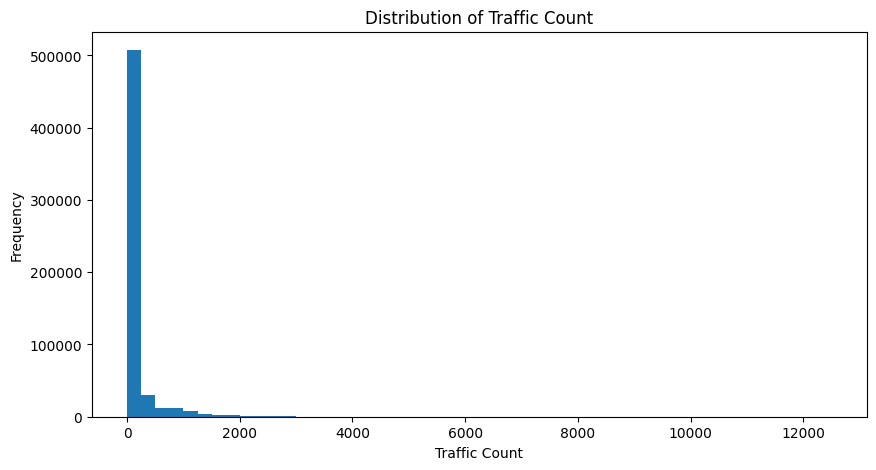

In [17]:
plt.figure(figsize=(10,5))
plt.hist(df_hourly["count"], bins=50)
plt.title("Distribution of Traffic Count")
plt.xlabel("Traffic Count")
plt.ylabel("Frequency")
plt.show()

This plot helps assess the shape of the hourly traffic distribution, including whether it is symmetric, skewed, or affected by extreme values. In traffic data, histograms are particularly useful because they show whether most observations are concentrated at low volumes or spread across a wider range of activity levels.

### Log-Transformed Histogram

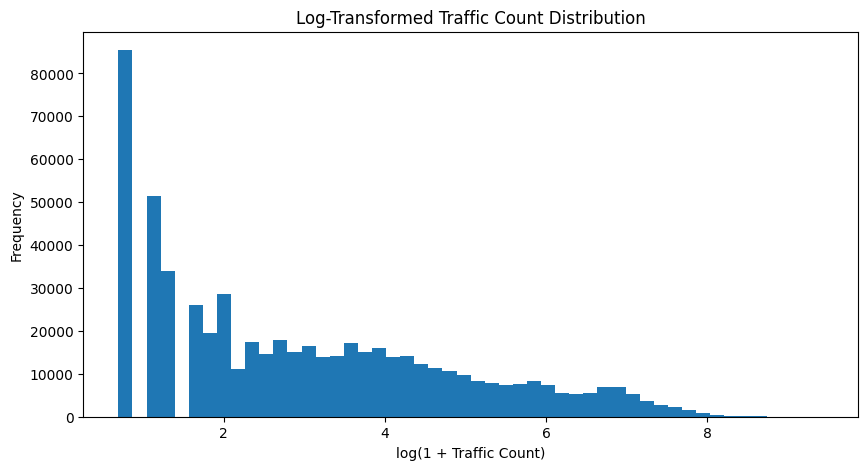

In [18]:
import numpy as np

plt.figure(figsize=(10,5))
plt.hist(np.log1p(df_hourly["count"]), bins=50)
plt.title("Log-Transformed Traffic Count Distribution")
plt.xlabel("log(1 + Traffic Count)")
plt.ylabel("Frequency")
plt.show()

The initial histogram of traffic counts appeared highly skewed and difficult to interpret due to the presence of extreme values. Most observations were concentrated at very low counts, while a small number of large values extended the scale significantly. To improve interpretability, a log transformation visualization was applied, revealing the underlying distribution more clearly.

The histogram of the log-transformed traffic count demonstrates a significantly improved distribution compared to the original highly skewed data. The transformation compresses extreme values while preserving the relative ordering of observations, resulting in a smoother and more continuous distribution. Although the data remains moderately right-skewed, the long tail is substantially reduced, making the dataset more suitable for machine learning models. The concentration of observations at lower values reflects typical traffic conditions, while the extended tail captures less frequent congestion events. This transformation ensures that extreme values do not disproportionately influence model training while still retaining critical information about peak traffic periods.

### Count by "Class"

In [19]:
df_hourly["class"].value_counts()

,count
class,
pedestrian,149900
cyclist,129540
motorbike,71919
escooter,67909
car,37934
van,31709
rigid,23241
bus,22522
minibus,17829


### Average Hourly Traffic Pattern by Class

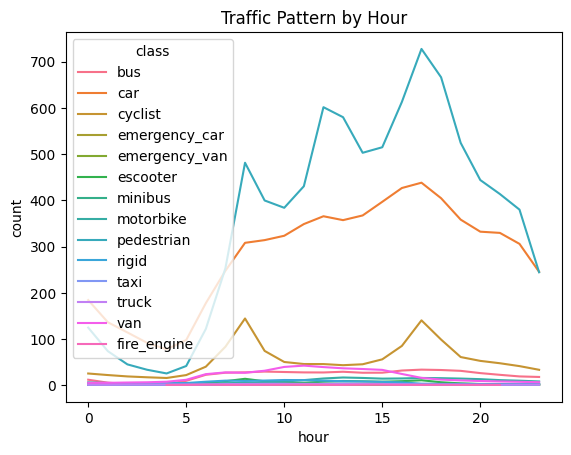

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_hourly.groupby(["hour", "class"], as_index=False)["count"].mean()
sns.lineplot(data=df_plot, x="hour", y="count", hue="class")
plt.title("Traffic Pattern by Hour")
plt.show()

The hourly traffic pattern plot reveals clear temporal variations across different transport classes, confirming that traffic activity follows a strong daily cycle. Most classes exhibit low activity during late-night hours, followed by a steady increase in the morning and peak activity during the afternoon period.

Pedestrian traffic dominates the dataset, reaching significantly higher volumes compared to other classes, suggesting that the data is likely collected in a dense urban environment. Car traffic shows a smoother pattern with a pronounced afternoon peak, while cyclists display distinct peaks corresponding to commuting hours.

In contrast, emergency-related vehicle classes maintain consistently low counts, reflecting their irregular nature. These observations highlight the heterogeneity of traffic behaviour and reinforce the importance of incorporating time-based features in subsequent analysis and modelling.

### Traffic Density Heatmap

Text(0.5, 1.0, 'Traffic Density Heatmap')

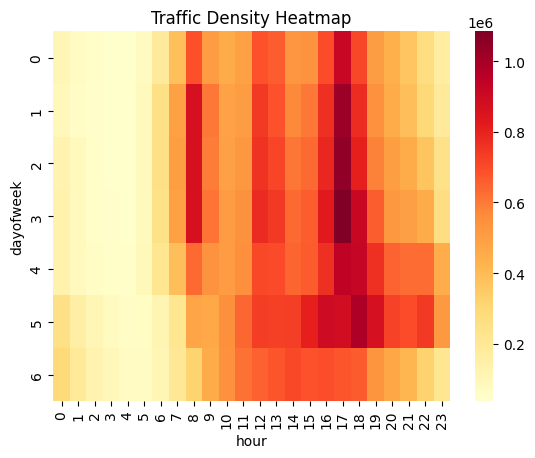

In [21]:
pivot = df_hourly.pivot_table(
    values="count",
    index="dayofweek",
    columns="hour",
    aggfunc="sum"
)

sns.heatmap(pivot, cmap="YlOrRd")
plt.title("Traffic Density Heatmap")

The traffic density heatmap provides a comprehensive view of how transport activity varies across both hours of the day and days of the week. The results reveal a clear temporal structure, with minimal activity during late-night hours and significant increases during typical commuting periods.

A pronounced morning peak is observed around 7–9 AM, followed by an even stronger afternoon peak between 15–18 PM, particularly on mid-week days. These patterns reflect regular work-related travel behaviour and confirm the presence of daily traffic cycles.

In contrast, weekend traffic appears more evenly distributed, with less distinct peaks, indicating more flexible movement patterns. The heatmap also highlights that mid-week days experience the highest levels of congestion, suggesting increased economic and commuting activity. Overall, these findings demonstrate that traffic density is strongly influenced by both time of day and day of week, reinforcing the importance of temporal feature engineering in subsequent analysis and modelling.

### Top Locations by Total Traffic

<Axes: xlabel='countLocationName'>

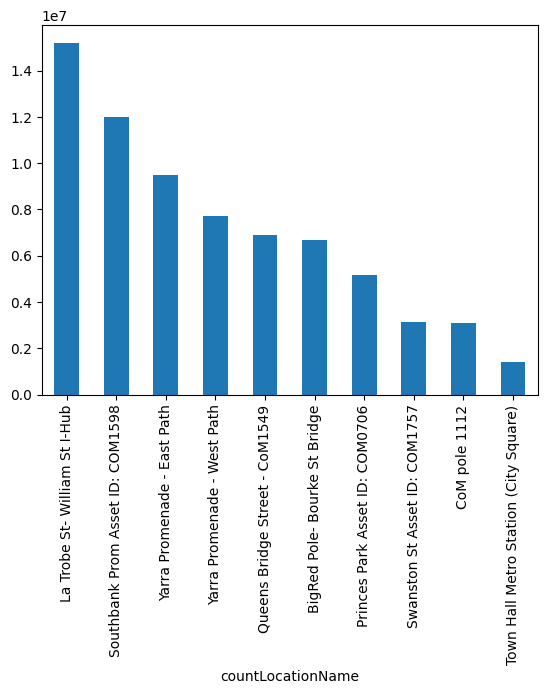

In [22]:
top_locations = df_hourly.groupby("countLocationName")["count"].sum().nlargest(10)

top_locations.plot(kind="bar")

## MODEL TRAINING

After completing the exploratory data analysis and hourly feature engineering, the next step is to build predictive models for traffic activity. In this project, the hourly traffic count is used as the target variable, while temporal, categorical, and location-based features are used as predictors.

This modelling stage aims to establish a baseline understanding of how well traffic volume can be predicted from historical traffic patterns alone. The results can later serve as a foundation for integrating weather variables and using LLM-based explanations to describe how environmental conditions may influence traffic behaviour.

### Feature Selection

In [23]:
# =========================
# 1. Feature selection
# =========================
import numpy as np

model_df = df_hourly.copy()

# Optional: log-transform target to reduce skewness
model_df["log_count"] = np.log1p(model_df["count"])

# Create additional time-based features
model_df["is_morning_peak"] = model_df["hour"].isin([7, 8, 9]).astype(int)
model_df["is_evening_peak"] = model_df["hour"].isin([16, 17, 18]).astype(int)

# Cyclical encoding for hour
model_df["hour_sin"] = np.sin(2 * np.pi * model_df["hour"] / 24)
model_df["hour_cos"] = np.cos(2 * np.pi * model_df["hour"] / 24)

# Cyclical encoding for day of week
model_df["dayofweek_sin"] = np.sin(2 * np.pi * model_df["dayofweek"] / 7)
model_df["dayofweek_cos"] = np.cos(2 * np.pi * model_df["dayofweek"] / 7)

# Features for baseline modelling
feature_cols = [
    "hour",
    "dayofweek",
    "month",
    "is_weekend",
    "is_morning_peak",
    "is_evening_peak",
    "hour_sin",
    "hour_cos",
    "dayofweek_sin",
    "dayofweek_cos",
    "class",
    "countLocationName"
]

X = model_df[feature_cols]
y = model_df["log_count"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nSelected features:")
print(feature_cols)

Feature matrix shape: (580944, 12)
Target shape: (580944,)

Selected features:
['hour', 'dayofweek', 'month', 'is_weekend', 'is_morning_peak', 'is_evening_peak', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'class', 'countLocationName']


In this step, I prepared the dataset for modelling by selecting relevant features and creating additional variables that could better represent traffic patterns.

First, the original hourly dataset was copied to avoid modifying the raw data. The target variable (count) was then transformed using a log transformation (log_count) to reduce skewness and stabilise variance. This is particularly useful because traffic count data is often highly skewed, and transforming it can improve model performance.

Next, I introduced several time-based features to capture meaningful patterns in traffic behaviour. Binary indicators such as 'is_morning_peak and 'is_evening_peak' were created to explicitly represent peak traffic periods, which are known to have significant impact on traffic volume.

In addition, cyclical encoding was applied to both the hour of the day and the day of the week. Instead of treating these variables as linear values, sine and cosine transformations were used to preserve their circular nature (e.g. 23:00 is close to 00:00). This helps the model better understand temporal relationships.

Finally, a combination of temporal features (hour, dayofweek, month, is_weekend), engineered features (peak indicators and cyclical variables), and categorical features (class and countLocationName) were selected as predictors. The resulting feature matrix contains 580,944 observations with 12 features, providing a rich representation of traffic patterns for model training.

### Data Preprocessing for Model Training

In [32]:
# =========================
# 2. Preprocessing
# =========================
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "hour",
    "dayofweek",
    "month",
    "is_weekend",
    "is_morning_peak",
    "is_evening_peak",
    "hour_sin",
    "hour_cos",
    "dayofweek_sin",
    "dayofweek_cos"
]

categorical_features = ["class", "countLocationName"]
# categorical_features = ["class"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (464755, 12)
Testing set: (116189, 12)


After defining the feature set, the next step was to prepare the data in a format suitable for machine learning models.

To do this, the predictors were divided into two groups: numeric features and categorical features. The numeric variables included the original time-based features as well as the engineered peak-hour and cyclical features. These were standardised using StandardScaler so that they would be placed on a comparable scale. This is especially helpful for models such as Linear Regression, where feature scale can affect learning behaviour and coefficient balance.

The categorical variables, 'class' and 'countLocationName', were transformed using OneHotEncoder. This step converts text-based categories into a numerical representation that machine learning algorithms can process. The handle_unknown="ignore" setting was used to ensure that the pipeline remains stable if unseen categories appear in the test set.

A 'ColumnTransformer' was then used to apply the appropriate transformation to each feature type in a single preprocessing pipeline. This makes the workflow cleaner, more consistent, and easier to reuse across multiple models.

Finally, the dataset was split into training and testing sets using an 80:20 ratio. This allows the models to be trained on one portion of the data and evaluated on unseen data, which is important for assessing how well the models generalise beyond the training sample.

### Model Selection and Training Setup

In [33]:
# =========================
# 3. Model training
# =========================
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=50,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
}

trained_models = {}

With the data fully prepared, the next step was to define and initialise the models used for prediction.

In this stage, I selected three different regression models to provide a balanced comparison between simple and more advanced approaches. Linear Regression was used as a baseline model due to its simplicity and interpretability. It helps establish a reference point for understanding how well traffic patterns can be explained using a linear relationship between features and the target variable.

To capture more complex and non-linear relationships, two tree-based models were also included: Random Forest and Gradient Boosting. Random Forest works by combining multiple decision trees to improve stability and reduce overfitting, while Gradient Boosting builds trees sequentially to progressively correct errors made by previous models. These models are particularly suitable for traffic data, where patterns are often influenced by multiple interacting factors.

Both tree-based models were configured with a limited number of estimators (50) to balance performance and computational efficiency. This ensures that the models remain practical to train while still being powerful enough to capture meaningful patterns in the data.

By comparing these three models, the goal is to evaluate how model complexity affects predictive performance, and to identify which approach provides the best trade-off between accuracy and efficiency for this problem.

### Model Evaluation and Performance Comparison

In [34]:
# =========================
# 4. Evaluation with progress tracking
# =========================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import pandas as pd
import numpy as np
import time

results = []

# ============================================================
# 1. Linear Regression
# ============================================================
print("=" * 70)
print("MODEL 1: Linear Regression")
print("=" * 70)

start_time = time.time()

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

print("Step 1: Fitting Linear Regression...")
lr_pipeline.fit(X_train, y_train)

print("Step 2: Predicting on test set...")
y_pred_lr = lr_pipeline.predict(X_test)

print("Step 3: Calculating metrics...")
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

elapsed_lr = time.time() - start_time

print(f"Linear Regression completed in {elapsed_lr:.2f} seconds")
print(f"MAE  : {mae_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"R2   : {r2_lr:.4f}")
print()

results.append({
    "Model": "Linear Regression",
    "MAE": mae_lr,
    "RMSE": rmse_lr,
    "R2": r2_lr,
    "Time (s)": elapsed_lr
})


# ============================================================
# 2. Random Forest (step-by-step with warm_start)
# ============================================================
print("=" * 70)
print("MODEL 2: Random Forest")
print("=" * 70)

# rf_steps = [10, 20, 30, 40, 50]
rf_steps = [10, 20]

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=10,
        warm_start=True,
        random_state=42,
        n_jobs=-1
    ))
])

start_time = time.time()

for n in rf_steps:
    print(f"Training Random Forest with {n} trees...")

    rf_pipeline.named_steps["model"].n_estimators = n
    rf_pipeline.fit(X_train, y_train)

    y_pred_rf_step = rf_pipeline.predict(X_test)

    mae_step = mean_absolute_error(y_test, y_pred_rf_step)
    rmse_step = np.sqrt(mean_squared_error(y_test, y_pred_rf_step))
    r2_step = r2_score(y_test, y_pred_rf_step)

    print(f" -> Trees: {n:>3} | MAE: {mae_step:.4f} | RMSE: {rmse_step:.4f} | R2: {r2_step:.4f}")
    print()

# Final RF metrics
elapsed_rf = time.time() - start_time

mae_rf = mae_step
rmse_rf = rmse_step
r2_rf = r2_step

print(f"Random Forest completed in {elapsed_rf:.2f} seconds")
print(f"Final MAE  : {mae_rf:.4f}")
print(f"Final RMSE : {rmse_rf:.4f}")
print(f"Final R2   : {r2_rf:.4f}")
print()

results.append({
    "Model": "Random Forest",
    "MAE": mae_rf,
    "RMSE": rmse_rf,
    "R2": r2_rf,
    "Time (s)": elapsed_rf
})


# ============================================================
# 3. Gradient Boosting (verbose each boosting iteration)
# ============================================================
print("=" * 70)
print("MODEL 3: Gradient Boosting")
print("=" * 70)

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        verbose=1
    ))
])

start_time = time.time()

print("Training Gradient Boosting...")
gb_pipeline.fit(X_train, y_train)

print("Predicting on test set...")
y_pred_gb = gb_pipeline.predict(X_test)

print("Calculating metrics...")
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

elapsed_gb = time.time() - start_time

print(f"Gradient Boosting completed in {elapsed_gb:.2f} seconds")
print(f"MAE  : {mae_gb:.4f}")
print(f"RMSE : {rmse_gb:.4f}")
print(f"R2   : {r2_gb:.4f}")
print()

results.append({
    "Model": "Gradient Boosting",
    "MAE": mae_gb,
    "RMSE": rmse_gb,
    "R2": r2_gb,
    "Time (s)": elapsed_gb
})


# ============================================================
# 4. Final comparison table
# ============================================================
results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)

print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)
print(results_df)

MODEL 1: Linear Regression
Step 1: Fitting Linear Regression...
Step 2: Predicting on test set...
Step 3: Calculating metrics...
Linear Regression completed in 2.42 seconds
MAE  : 0.8046
RMSE : 1.0450
R2   : 0.6982

MODEL 2: Random Forest
Training Random Forest with 10 trees...
 -> Trees:  10 | MAE: 0.3613 | RMSE: 0.5403 | R2: 0.9193

Training Random Forest with 20 trees...
 -> Trees:  20 | MAE: 0.3594 | RMSE: 0.5370 | R2: 0.9203

Random Forest completed in 1670.59 seconds
Final MAE  : 0.3594
Final RMSE : 0.5370
Final R2   : 0.9203

MODEL 3: Gradient Boosting
Training Gradient Boosting...
      Iter       Train Loss   Remaining Time 
         1           3.2695            1.17m
         2           2.9918            1.14m
         3           2.7650            1.14m
         4           2.5806            1.12m
         5           2.4292            1.10m
         6           2.3046            1.09m
         7           2.2013            1.08m
         8           2.1140            1.08

After defining the three candidate models, I evaluated them using a consistent training and testing workflow. For each model, I combined the preprocessing step and the regression algorithm into a single pipeline. This ensured that the same data transformation process was applied fairly across all models, making the comparison more reliable.

To assess model performance, I used three standard regression metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score. MAE shows the average size of prediction errors, RMSE gives more weight to larger errors, and R² indicates how much of the variation in traffic count can be explained by the model. In addition, training time was also recorded to compare computational efficiency.

- Linear Regression was evaluated first as a simple baseline model. It completed training very quickly and achieved a reasonably strong result, with an R² score of 0.698. This suggests that the selected features already contain meaningful predictive information, even under a relatively simple linear modelling approach.

- Random Forest was then trained incrementally using warm start, allowing performance to be observed as the number of trees increased. The results improved slightly from 10 trees to 20 trees, and the final model achieved the best overall predictive performance, with an R² score of 0.920 and the lowest error values among all three models. This indicates that the model was able to capture complex and non-linear traffic patterns much more effectively than the linear baseline.

- Gradient Boosting also showed improved performance over Linear Regression, achieving an R² score of 0.743. However, although it performed better than the baseline, it still remained below the Random Forest result. It also required noticeably longer training time than Linear Regression, though still much less than the Random Forest configuration used in this experiment.

Overall, Random Forest produced the strongest predictive accuracy, while Linear Regression remained the most efficient in terms of computation time. This suggests that there is a clear trade-off between accuracy and efficiency in this modelling stage. For this dataset, tree-based methods appear to be more suitable for capturing traffic behaviour than a simple linear model.

At the same time, the very strong Random Forest result should be interpreted carefully. Because location-based features such as 'countLocationName' were included, the model may be learning highly specific traffic patterns associated with individual locations. This is useful for prediction within the current dataset, but it may also reduce generalisability if the model is later applied to new locations or broader traffic scenarios. Therefore, while Random Forest can be considered the best-performing model in this experiment, the result should still be discussed with some caution.